In [2]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
from PIL import Image
from scipy import ndimage
import tensorflow as tf
from tensorflow.python.framework import ops
from cnn_utils import *

get_ipython().run_line_magic('matplotlib', 'inline')
np.random.seed(1)

In [3]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

y = 2


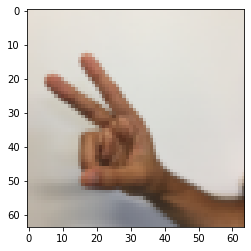

In [4]:
index = 6
plt.imshow(X_train_orig[index])
print ("y = " + str(np.squeeze(Y_train_orig[:, index])))

In [5]:
X_train = X_train_orig/255.
X_test = X_test_orig/255.
Y_train = convert_to_one_hot(Y_train_orig, 6).T
Y_test = convert_to_one_hot(Y_test_orig, 6).T
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))
conv_layers = {}

number of training examples = 1080
number of test examples = 120
X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080, 6)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120, 6)


In [86]:
def create_placeholders(n_H0, n_W0, n_C0, n_y):
    """
    Creates the placeholders for the tensorflow session.
    
    Arguments:
    n_H0 -- scalar, height of an input image
    n_W0 -- scalar, width of an input image
    n_C0 -- scalar, number of channels of the input
    n_y -- scalar, number of classes
        
    Returns:
    X -- placeholder for the data input, of shape [None, n_H0, n_W0, n_C0] and dtype "float"
    Y -- placeholder for the input labels, of shape [None, n_y] and dtype "float"
    """

    ### START CODE HERE ### (≈2 lines)
    X = tf.placeholder(tf.float32,shape=([None,n_H0,n_W0,n_C0]),name='Placeholder1') 
    Y = tf.placeholder(tf.float32,shape=([None,n_y]),name='Placeholder2')
    keep_prob = tf.placeholder(tf.float32,name='Placeholder3')

    ### END CODE HERE ###
    
    return X, Y,keep_prob


In [87]:
X, Y,keep_prob = create_placeholders(64, 64, 3, 6)
print ("X = " + str(X))
print ("Y = " + str(Y))

X = Tensor("Placeholder1_1:0", shape=(?, 64, 64, 3), dtype=float32)
Y = Tensor("Placeholder2_1:0", shape=(?, 6), dtype=float32)


In [88]:
def initialize_parameters():
    """
    Initializes weight parameters to build a neural network with tensorflow. The shapes are:
                        W1 : [4, 4, 3, 8]
                        W2 : [2, 2, 8, 16]
    Returns:
    parameters -- a dictionary of tensors containing W1, W2
    """
    
    tf.set_random_seed(1)                              # so that your "random" numbers match ours
        
    ### START CODE HERE ### (approx. 2 lines of code)
    W1 =  tf.get_variable("W1",[4,4,3,8],initializer=tf.contrib.layers.xavier_initializer(seed=0))
    W2 =  tf.get_variable("W2",[2,2,8,16],initializer=tf.contrib.layers.xavier_initializer(seed=0))
    W3 =  tf.get_variable("W3",[2,2,16,8],initializer=tf.contrib.layers.xavier_initializer(seed=0))
    
    ### END CODE HERE ###

    parameters = {"W1": W1,
                  "W2": W2,
                  "W3": W3
                  }
    
    return parameters

In [89]:
tf.reset_default_graph()
with tf.Session() as sess_test:
    parameters = initialize_parameters()
    init = tf.global_variables_initializer()
    sess_test.run(init)
    print("W1 = " + str(parameters["W1"].eval()[1,1,1]))
    print("W2 = " + str(parameters["W2"].eval()[1,1,1]))

W1 = [ 0.00131723  0.1417614  -0.04434952  0.09197326  0.14984085 -0.03514394
 -0.06847463  0.05245192]
W2 = [-0.08566415  0.17750949  0.11974221  0.16773748 -0.0830943  -0.08058
 -0.00577033 -0.14643836  0.24162132 -0.05857408 -0.19055021  0.1345228
 -0.22779644 -0.1601823  -0.16117483 -0.10286498]


In [90]:
def forward_propagation(X, parameters,keep_prob):
    """
    Implements the forward propagation for the model:
    CONV2D -> RELU -> MAXPOOL -> CONV2D -> RELU -> MAXPOOL -> FLATTEN -> FULLYCONNECTED
    
    Arguments:
    X -- input dataset placeholder, of shape (input size, number of examples)
    parameters -- python dictionary containing your parameters "W1", "W2"
                  the shapes are given in initialize_parameters

    Returns:
    Z3 -- the output of the last LINEAR unit
    """

    # Retrieve the parameters from the dictionary "parameters" 
    W1 = parameters['W1']
    W2 = parameters['W2']
    W3 = parameters['W3']
    ### START CODE HERE ###
    # CONV2D: stride of 1, padding 'SAME'
    Z1 =  tf.nn.conv2d(X,filter=W1,strides=(1,1,1,1),padding="SAME")
    # RELU
    A1 =  tf.nn.relu(Z1)
    #A1=tf.nn.dropout(A1,keep_prob)
    # MAXPOOL: window 8x8, sride 8, padding 'SAME'
    P1 =  tf.nn.max_pool(A1,ksize=(1,8,8,1),strides=(1,8,8,1),padding='SAME')
    # CONV2D: filters W2, stride 1, padding 'SAME'
    Z2 =  tf.nn.conv2d(P1,filter=W2,strides=(1,1,1,1),padding="SAME")
    # RELU
    A2 =  tf.nn.relu(Z2)
    #A2=tf.nn.dropout(A2,keep_prob)
    # MAXPOOL: window 4x4, stride 4, padding 'SAME'
    P2 =  tf.nn.max_pool(A2,ksize=(1,4,4,1),strides=(1,4,4,1),padding="SAME")
    Z3 =  tf.nn.conv2d(P2,filter=W3,strides=(1,1,1,1),padding="SAME")
    A3 =  tf.nn.relu(Z3)
    #A3=tf.nn.dropout(A3,keep_prob)
    P3 =  tf.nn.max_pool(A3,ksize=(1,2,2,1),strides=(1,2,2,1),padding="SAME")
    # FLATTEN
    F =  tf.contrib.layers.flatten(P2)
    # FULLY-CONNECTED without non-linear activation function (not not call softmax).
    # 6 neurons in output layer. Hint: one of the arguments should be "activation_fn=None" 
    Z3 =  tf.contrib.layers.fully_connected(F,activation_fn=None,num_outputs=6)
    ### END CODE HERE ###

    return Z3

In [91]:
tf.reset_default_graph()

with tf.Session() as sess:
    np.random.seed(1)
    X, Y,keep_prob = create_placeholders(64, 64, 3, 6)
    parameters = initialize_parameters()
    Z3 = forward_propagation(X, parameters,keep_prob=0.5)
    init = tf.global_variables_initializer()
    sess.run(init)
    a = sess.run(Z3, {X: np.random.randn(2,64,64,3), Y: np.random.randn(2,6)})
    print("Z3 = " + str(a))


Z3 = [[-4.3465505   2.5202992   0.5947281   1.1023566  -1.2177956   4.3851194 ]
 [-4.3653336   2.4119408   0.36408505  0.9514738  -0.830896    4.242732  ]]


In [103]:
def compute_cost(Z3, Y,parameters, lambd):
    """
    Computes the cost
    
    Arguments:
    Z3 -- output of forward propagation (output of the last LINEAR unit), of shape (6, number of examples)
    Y -- "true" labels vector placeholder, same shape as Z3
    
    Returns:
    cost - Tensor of the cost function
    """
    m = Y.shape[1]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]
    regularizer = tf.nn.l2_loss(W1)+tf.nn.l2_loss(W2)+tf.nn.l2_loss(W3)
    ### START CODE HERE ### (1 line of code)
    cost =  tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=Z3,labels=Y))
    ### END CODE HERE ###
    cost = tf.reduce_mean(cost + lambd * regularizer)
    return cost

In [104]:
tf.reset_default_graph()

with tf.Session() as sess:
    np.random.seed(1)
    X, Y,keep_prob= create_placeholders(64, 64, 3, 6)
    parameters = initialize_parameters()
    Z3 = forward_propagation(X, parameters,keep_prob=0.5)
    cost = compute_cost(Z3, Y,parameters, lambd=0.1)
    init = tf.global_variables_initializer()
    sess.run(init)
    a = sess.run(cost, {X: np.random.randn(4,64,64,3), Y: np.random.randn(4,6)})
    print("cost = " + str(a))


cost = 0.836673


In [105]:
def model(X_train, Y_train, X_test, Y_test, learning_rate = 0.009,lambd=0.1,
          num_epochs = 200, minibatch_size = 64, print_cost = True):
    """
    Implements a three-layer ConvNet in Tensorflow:
    CONV2D -> RELU -> MAXPOOL -> CONV2D -> RELU -> MAXPOOL -> FLATTEN -> FULLYCONNECTED
    
    Arguments:
    X_train -- training set, of shape (None, 64, 64, 3)
    Y_train -- test set, of shape (None, n_y = 6)
    X_test -- training set, of shape (None, 64, 64, 3)
    Y_test -- test set, of shape (None, n_y = 6)
    learning_rate -- learning rate of the optimization
    num_epochs -- number of epochs of the optimization loop
    minibatch_size -- size of a minibatch
    print_cost -- True to print the cost every 100 epochs
    
    Returns:
    train_accuracy -- real number, accuracy on the train set (X_train)
    test_accuracy -- real number, testing accuracy on the test set (X_test)
    parameters -- parameters learnt by the model. They can then be used to predict.
    """
    
    ops.reset_default_graph()                         # to be able to rerun the model without overwriting tf variables
    tf.set_random_seed(1)                             # to keep results consistent (tensorflow seed)
    seed = 3                                          # to keep results consistent (numpy seed)
    (m, n_H0, n_W0, n_C0) = X_train.shape             
    n_y = Y_train.shape[1]                            
    costs = []                                        # To keep track of the cost
    
    # Create Placeholders of the correct shape
    ### START CODE HERE ### (1 line)
    X, Y,keep_prob =  create_placeholders(n_H0, n_W0, n_C0, n_y)
    ### END CODE HERE ###

    # Initialize parameters
    ### START CODE HERE ### (1 line)
    parameters =  initialize_parameters()
    ### END CODE HERE ###
    
    # Forward propagation: Build the forward propagation in the tensorflow graph
    ### START CODE HERE ### (1 line)
    Z3 =  forward_propagation(X,parameters,keep_prob=1)
    ### END CODE HERE ###
    
    # Cost function: Add cost function to tensorflow graph
    ### START CODE HERE ### (1 line)
    cost =  compute_cost(Z3, Y,parameters, lambd)
    ### END CODE HERE ###

    # Backpropagation: Define the tensorflow optimizer. Use an AdamOptimizer that minimizes the cost.
    ### START CODE HERE ### (1 line)
    optimizer =  tf.train.RMSPropOptimizer(learning_rate=learning_rate).minimize(cost)
    ### END CODE HERE ###
    
    # Initialize all the variables globally
    init = tf.global_variables_initializer()
     
    # Start the session to compute the tensorflow graph
    with tf.Session() as sess:
        
        # Run the initialization
        sess.run(init)
        
        # Do the training loop
        for epoch in range(num_epochs):

            minibatch_cost = 0.
            num_minibatches = int(m / minibatch_size) # number of minibatches of size minibatch_size in the train set
            seed = seed + 1
            minibatches = random_mini_batches(X_train, Y_train, minibatch_size, seed)

            for minibatch in minibatches:

                # Select a minibatch
                (minibatch_X, minibatch_Y) = minibatch
                # IMPORTANT: The line that runs the graph on a minibatch.
                # Run the session to execute the optimizer and the cost, the feedict should contain a minibatch for (X,Y).
                ### START CODE HERE ### (1 line)
                _ , temp_cost =  sess.run([optimizer,cost],feed_dict={X:minibatch_X, Y:minibatch_Y})
                ### END CODE HERE ###
                
                minibatch_cost += temp_cost / num_minibatches
                
            predict_op = tf.argmax(Z3, 1)
            correct_prediction = tf.equal(predict_op, tf.argmax(Y, 1))

            # Calculate accuracy on the test set
            accuracy = tf.reduce_mean(tf.cast(correct_prediction, "float"))
            train_accuracy = accuracy.eval({X: X_train, Y: Y_train})
            test_accuracy = accuracy.eval({X: X_test, Y: Y_test})
            
            # Print the cost every epoch
            if print_cost == True and epoch % 5 == 0:
                print ("Cost after epoch %i: %f" % (epoch, minibatch_cost))
                print("Train Accuracy:", train_accuracy)
                print("Test Accuracy:", test_accuracy)
            if print_cost == True and epoch % 1 == 0:
                costs.append(minibatch_cost)
            if test_accuracy >0.94:
                break
           
        
        
        # plot the cost
        plt.plot(np.squeeze(costs))
        plt.ylabel('cost')
        plt.xlabel('iterations (per tens)')
        plt.title("Learning rate =" + str(learning_rate))
        plt.show()

        # Calculate the correct predictions
        #predict_op = tf.argmax(Z3, 1)
        #correct_prediction = tf.equal(predict_op, tf.argmax(Y, 1))
        
        # Calculate accuracy on the test set
        #accuracy = tf.reduce_mean(tf.cast(correct_prediction, "float"))
        #print(accuracy)
        #train_accuracy = accuracy.eval({X: X_train, Y: Y_train})
        #test_accuracy = accuracy.eval({X: X_test, Y: Y_test})
        #print("Train Accuracy:", train_accuracy)
        #print("Test Accuracy:", test_accuracy)
                
        return train_accuracy, test_accuracy, parameters

Cost after epoch 0: 3.384955
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 5: 1.942777
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 10: 1.908075
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 15: 1.909728
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 20: 1.906692
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 25: 1.923535
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 30: 1.908741
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 35: 1.909120
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 40: 1.907379
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 45: 1.909701
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 50: 1.909043
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 55: 1.908619
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost a

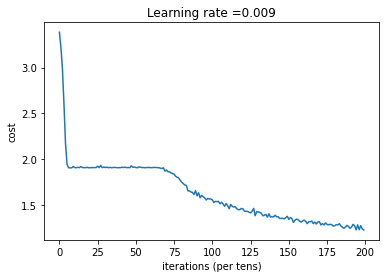

In [106]:
_, _, parameters = model(X_train, Y_train, X_test, Y_test)

In [97]:
def model(X_train, Y_train, X_test, Y_test, learning_rate = 0.009,lambd=0,
          num_epochs = 200, minibatch_size = 64, print_cost = True,keep_prob=1):
    """
    Implements a three-layer ConvNet in Tensorflow:
    CONV2D -> RELU -> MAXPOOL -> CONV2D -> RELU -> MAXPOOL -> FLATTEN -> FULLYCONNECTED
    
    Arguments:
    X_train -- training set, of shape (None, 64, 64, 3)
    Y_train -- test set, of shape (None, n_y = 6)
    X_test -- training set, of shape (None, 64, 64, 3)
    Y_test -- test set, of shape (None, n_y = 6)
    learning_rate -- learning rate of the optimization
    num_epochs -- number of epochs of the optimization loop
    minibatch_size -- size of a minibatch
    print_cost -- True to print the cost every 100 epochs
    
    Returns:
    train_accuracy -- real number, accuracy on the train set (X_train)
    test_accuracy -- real number, testing accuracy on the test set (X_test)
    parameters -- parameters learnt by the model. They can then be used to predict.
    """
    
    ops.reset_default_graph()                         # to be able to rerun the model without overwriting tf variables
    tf.set_random_seed(1)                             # to keep results consistent (tensorflow seed)
    seed = 3                                          # to keep results consistent (numpy seed)
    (m, n_H0, n_W0, n_C0) = X_train.shape             
    n_y = Y_train.shape[1]                            
    costs = []                                        # To keep track of the cost
    
    # Create Placeholders of the correct shape
    ### START CODE HERE ### (1 line)
    X, Y,keep_prob =  create_placeholders(n_H0, n_W0, n_C0, n_y)
    ### END CODE HERE ###

    # Initialize parameters
    ### START CODE HERE ### (1 line)
    parameters =  initialize_parameters()
    ### END CODE HERE ###
    
    # Forward propagation: Build the forward propagation in the tensorflow graph
    ### START CODE HERE ### (1 line)
    Z3 =  forward_propagation(X,parameters,keep_prob)
    ### END CODE HERE ###
    
    # Cost function: Add cost function to tensorflow graph
    ### START CODE HERE ### (1 line)
    cost =  compute_cost(Z3, Y,parameters, lambd)
    ### END CODE HERE ###

    # Backpropagation: Define the tensorflow optimizer. Use an AdamOptimizer that minimizes the cost.
    ### START CODE HERE ### (1 line)
    optimizer =  tf.train.RMSPropOptimizer(learning_rate=learning_rate).minimize(cost)
    ### END CODE HERE ###
    
    # Initialize all the variables globally
    init = tf.global_variables_initializer()
     
    # Start the session to compute the tensorflow graph
    with tf.Session() as sess:
        
        # Run the initialization
        sess.run(init)
        
        # Do the training loop
        for epoch in range(num_epochs):

            minibatch_cost = 0.
            num_minibatches = int(m / minibatch_size) # number of minibatches of size minibatch_size in the train set
            seed = seed + 1
            minibatches = random_mini_batches(X_train, Y_train, minibatch_size, seed)

            for minibatch in minibatches:

                # Select a minibatch
                (minibatch_X, minibatch_Y) = minibatch
                # IMPORTANT: The line that runs the graph on a minibatch.
                # Run the session to execute the optimizer and the cost, the feedict should contain a minibatch for (X,Y).
                ### START CODE HERE ### (1 line)
                _ , temp_cost =  sess.run([optimizer,cost],feed_dict={X:minibatch_X, Y:minibatch_Y})
                ### END CODE HERE ###
                
                minibatch_cost += temp_cost / num_minibatches
                
            predict_op = tf.argmax(Z3, 1)
            correct_prediction = tf.equal(predict_op, tf.argmax(Y, 1))

            # Calculate accuracy on the test set
            accuracy = tf.reduce_mean(tf.cast(correct_prediction, "float"))
            train_accuracy = accuracy.eval({X: X_train, Y: Y_train})
            test_accuracy = accuracy.eval({X: X_test, Y: Y_test})
            
            # Print the cost every epoch
            if print_cost == True and epoch % 5 == 0:
                print ("Cost after epoch %i: %f" % (epoch, minibatch_cost))
                print("Train Accuracy:", train_accuracy)
                print("Test Accuracy:", test_accuracy)
            if print_cost == True and epoch % 1 == 0:
                costs.append(minibatch_cost)
            if test_accuracy >0.94:
                break
           
        
        
        # plot the cost
        plt.plot(np.squeeze(costs))
        plt.ylabel('cost')
        plt.xlabel('iterations (per tens)')
        plt.title("Learning rate =" + str(learning_rate))
        plt.show()

        # Calculate the correct predictions
        #predict_op = tf.argmax(Z3, 1)
        #correct_prediction = tf.equal(predict_op, tf.argmax(Y, 1))
        
        # Calculate accuracy on the test set
        #accuracy = tf.reduce_mean(tf.cast(correct_prediction, "float"))
        #print(accuracy)
        #train_accuracy = accuracy.eval({X: X_train, Y: Y_train})
        #test_accuracy = accuracy.eval({X: X_test, Y: Y_test})
        #print("Train Accuracy:", train_accuracy)
        #print("Test Accuracy:", test_accuracy)
                
        return train_accuracy, test_accuracy, parameters

Cost after epoch 0: 1.972887
Train Accuracy: 0.16666667
Test Accuracy: 0.16666667
Cost after epoch 5: 1.895064
Train Accuracy: 0.26574075
Test Accuracy: 0.25
Cost after epoch 10: 1.463340
Train Accuracy: 0.48425925
Test Accuracy: 0.45833334
Cost after epoch 15: 1.005604
Train Accuracy: 0.71574074
Test Accuracy: 0.64166665
Cost after epoch 20: 0.791742
Train Accuracy: 0.7509259
Test Accuracy: 0.71666664
Cost after epoch 25: 0.605711
Train Accuracy: 0.8046296
Test Accuracy: 0.76666665
Cost after epoch 30: 0.514796
Train Accuracy: 0.7962963
Test Accuracy: 0.725
Cost after epoch 35: 0.465317
Train Accuracy: 0.9064815
Test Accuracy: 0.8666667
Cost after epoch 40: 0.345656
Train Accuracy: 0.9064815
Test Accuracy: 0.81666666
Cost after epoch 45: 0.322124
Train Accuracy: 0.90462965
Test Accuracy: 0.85
Cost after epoch 50: 0.323936
Train Accuracy: 0.92685187
Test Accuracy: 0.8333333
Cost after epoch 55: 0.283980
Train Accuracy: 0.9574074
Test Accuracy: 0.8666667
Cost after epoch 60: 0.246917
Tr

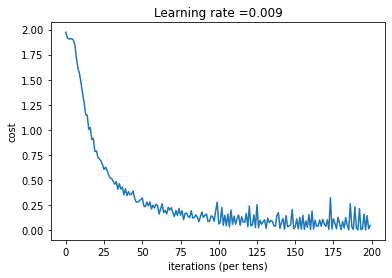

In [98]:
_, _, parameters = model(X_train, Y_train, X_test, Y_test)